# NLP Module 1 — Topics 4–10: Applications & Evaluation
### MT, QA, IR, Text Categorization, Summarization, Sentiment Analysis, Metrics
> 📚 MTech NLP Course — Module 1

---

In [ ]:
# !pip install nltk scikit-learn transformers torch sentencepiece rouge-score matplotlib pandas -q

In [ ]:
# ============================================================

# ── STEP 0: Install all dependencies (run once) ──
# !pip install nltk scikit-learn transformers torch sentencepiece rouge-score
# !pip install sacrebleu datasets

import nltk
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)

from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

STOP_WORDS = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess(text):
    """Standard preprocessing: lowercase → remove non-alpha → stem → remove stopwords."""
    tokens = re.findall(r'\b[a-zA-Z]+\b', text.lower())
    return ' '.join([stemmer.stem(t) for t in tokens if t not in STOP_WORDS])


### TOPIC 4: MACHINE TRANSLATION

In [ ]:
# ================================================================
# TOPIC 4: MACHINE TRANSLATION
# ================================================================
# 📜 HISTORICAL BACKGROUND
# • 1954: Georgetown-IBM Experiment — first public MT demonstration.
#   Translated 60 Russian sentences to English using 250 vocabulary words.
# • 1966: ALPAC Report — concluded MT was slower/poorer than human translators.
#   Led to a decade-long funding freeze (the "AI Winter" for MT).
# • 1980s–90s: Rule-Based MT (RBMT) — Systran, used by early Google Translate.
# • 1990s: Statistical MT (SMT) — IBM Models (Brown et al., 1993) using
#   parallel corpora (bilingual text pairs). Phrase-based SMT dominated 2000s.
# • 2014: Neural MT (NMT) — Sutskever et al.'s sequence-to-sequence LSTM.
# • 2017: Transformer (Vaswani et al.) — "Attention Is All You Need."
#   Replaced LSTMs; now the backbone of all production MT systems.

In [ ]:
# ================================================================
print("=" * 65)
print("🌐 TOPIC 4: Machine Translation")
print("=" * 65)

# ── PART A: Dictionary-Based (Word-for-Word) MT ──
print("\n─── PART A: Dictionary-Based MT (Simplest Approach) ───")
print("Historical analog: Early 1950s word-for-word substitution.")

# Small English → French dictionary
en_fr_dict = {
    'the': 'le', 'a': 'un', 'cat': 'chat', 'dog': 'chien',
    'is': 'est', 'are': 'sont', 'beautiful': 'beau', 'house': 'maison',
    'big': 'grand', 'small': 'petit', 'i': 'je', 'love': 'aime',
    'you': 'tu', 'and': 'et', 'not': 'ne pas', 'run': 'courir',
    'fast': 'vite', 'very': 'très', 'my': 'mon', 'friend': 'ami',
}

def dictionary_translate(sentence, dictionary):
    """
    Word-for-word translation using a bilingual dictionary.
    Limitation: no grammar, no word order adjustment.
    """
    tokens = sentence.lower().split()
    translated = [dictionary.get(tok, f"[{tok}]") for tok in tokens]
    return ' '.join(translated)

test_sentences = [
    "the cat is beautiful",
    "i love my friend very fast",
    "a big house and a small dog"
]
print("\n  English → French (Dictionary Method):")
for sent in test_sentences:
    translated = dictionary_translate(sent, en_fr_dict)
    print(f"  EN: {sent}")
    print(f"  FR: {translated}  ← (word order not adjusted)")
    print()

print("  ⚠️  Limitation: No grammar rules, no word reordering, no context.")


🌐 TOPIC 4: Machine Translation

─── PART A: Dictionary-Based MT (Simplest Approach) ───
Historical analog: Early 1950s word-for-word substitution.

  English → French (Dictionary Method):
  EN: the cat is beautiful
  FR: le chat est beau  ← (word order not adjusted)

  EN: i love my friend very fast
  FR: je aime mon ami très vite  ← (word order not adjusted)

  EN: a big house and a small dog
  FR: un grand maison et un petit chien  ← (word order not adjusted)

  ⚠️  Limitation: No grammar rules, no word reordering, no context.


In [ ]:

# ── PART B: Pretrained Neural MT (HuggingFace Helsinki-NLP) ──
print("\n─── PART B: Neural MT (Transformer-based, HuggingFace) ───")
print("Modern standard: Encoder-Decoder Transformer trained on parallel corpora.")

try:
    from transformers import MarianMTModel, MarianTokenizer

    model_name = "Helsinki-NLP/opus-mt-en-fr"
    print(f"\nLoading model: {model_name} (this may take a minute on first run)...")
    tokenizer = MarianTokenizer.from_pretrained(model_name)
    nmt_model  = MarianMTModel.from_pretrained(model_name)

    def neural_translate(sentences):
        """Translate a list of English sentences to French using MarianMT."""
        inputs = tokenizer(sentences, return_tensors="pt", padding=True, truncation=True)
        translated = nmt_model.generate(**inputs)
        return [tokenizer.decode(t, skip_special_tokens=True) for t in translated]

    nmt_inputs = [
        "Natural language processing enables computers to understand human language.",
        "The cat sat on the mat.",
        "Machine translation has improved dramatically since the 1950s."
    ]

    nmt_outputs = neural_translate(nmt_inputs)
    print("\n  English → French (Neural MT):")
    for en, fr in zip(nmt_inputs, nmt_outputs):
        print(f"  EN: {en}")
        print(f"  FR: {fr}")
        print()
except ImportError:
    print("  [Run: !pip install transformers sentencepiece to enable neural MT]")
except Exception as e:
    print(f"  [Neural MT example requires internet. Error: {e}]")



─── PART B: Neural MT (Transformer-based, HuggingFace) ───
Modern standard: Encoder-Decoder Transformer trained on parallel corpora.

Loading model: Helsinki-NLP/opus-mt-en-fr (this may take a minute on first run)...


tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/778k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/301M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]


  English → French (Neural MT):
  EN: Natural language processing enables computers to understand human language.
  FR: Le traitement du langage naturel permet aux ordinateurs de comprendre le langage humain.

  EN: The cat sat on the mat.
  FR: Le chat était assis sur le tapis.

  EN: Machine translation has improved dramatically since the 1950s.
  FR: La traduction automatique s'est considérablement améliorée depuis les années 1950.



In [ ]:

# COMPARISON TABLE
print("\n  📊 MT Methods Comparison:")
comparison_data = {
    'Method': ['Word-for-word\n(1950s)', 'Rule-Based MT\n(1970s–90s)',
               'Statistical MT\n(1990s–2010s)', 'Neural MT\n(2014+)'],
    'Fluency': ['Very Low', 'Medium', 'Good', 'Excellent'],
    'Accuracy': ['Low', 'Medium', 'Good', 'Excellent'],
    'Training Data': ['Dictionary', 'Grammar rules', 'Parallel corpus', 'Large parallel corpus'],
}
print(pd.DataFrame(comparison_data).to_string(index=False))



  📊 MT Methods Comparison:
                       Method   Fluency  Accuracy         Training Data
       Word-for-word\n(1950s)  Very Low       Low            Dictionary
   Rule-Based MT\n(1970s–90s)    Medium    Medium         Grammar rules
Statistical MT\n(1990s–2010s)      Good      Good       Parallel corpus
           Neural MT\n(2014+) Excellent Excellent Large parallel corpus


### TOPIC 5: QUESTION ANSWERING SYSTEM

In [ ]:
# ================================================================
# TOPIC 5: QUESTION ANSWERING SYSTEM
# ================================================================
# 📜 HISTORICAL BACKGROUND
# • 1961: BASEBALL (Green et al.) — first QA system; answered factual
#   questions about baseball games from a structured database.
# • 1966: ELIZA answered questions but only through pattern-matching.
# • 1993: START (Katz, MIT) — first web-based QA system.
# • 2001: IBM's DeepQA project began; led to Watson defeating
#   Jeopardy! champions in 2011 — a landmark moment for QA.
# • 2018: SQuAD benchmark (Stanford) standardized extractive QA evaluation.
# • 2019+: BERT-based models achieved human-level on SQuAD 1.1.

In [ ]:
# ================================================================
print("\n" + "=" * 65)
print("❓ TOPIC 5: Question Answering System")
print("=" * 65)

# ── PART A: Rule-Based / Keyword-Matching QA ──
print("\n─── PART A: Simple Keyword-Matching QA ───")

# Small FAQ knowledge base
faq_knowledge_base = [
    {"q": "What is NLP?",
     "a": "NLP (Natural Language Processing) is a field of AI that enables computers to understand and generate human language."},
    {"q": "Who created the Turing Test?",
     "a": "The Turing Test was proposed by Alan Turing in his 1950 paper 'Computing Machinery and Intelligence'."},
    {"q": "What is tokenization?",
     "a": "Tokenization is the process of splitting text into individual units called tokens, such as words or sentences."},
    {"q": "What is machine translation?",
     "a": "Machine translation is the use of software to translate text from one natural language to another."},
    {"q": "What is a transformer model?",
     "a": "A transformer is a deep learning architecture introduced in 2017 by Vaswani et al., based entirely on attention mechanisms."},
]

def keyword_qa(question, knowledge_base):
    """
    Simple QA: finds the most word-overlapping question in the KB.
    Returns the corresponding answer.
    """
    q_tokens = set(re.findall(r'\b[a-zA-Z]+\b', question.lower()))
    best_match, best_score = None, 0
    for item in knowledge_base:
        kb_tokens = set(re.findall(r'\b[a-zA-Z]+\b', item['q'].lower()))
        overlap = len(q_tokens & kb_tokens) / (len(q_tokens | kb_tokens) + 1e-9)
        if overlap > best_score:
            best_score = overlap
            best_match = item
    return best_match['a'] if best_match and best_score > 0.1 else "I don't know."

test_questions_simple = [
    "What is natural language processing?",
    "Who invented the Turing Test?",
    "Tell me about tokenization."
]
print("\n  Questions → Keyword-Matched Answers:")
for q in test_questions_simple:
    answer = keyword_qa(q, faq_knowledge_base)
    print(f"  Q: {q}")
    print(f"  A: {answer}")
    print()




❓ TOPIC 5: Question Answering System

─── PART A: Simple Keyword-Matching QA ───

  Questions → Keyword-Matched Answers:
  Q: What is natural language processing?
  A: NLP (Natural Language Processing) is a field of AI that enables computers to understand and generate human language.

  Q: Who invented the Turing Test?
  A: The Turing Test was proposed by Alan Turing in his 1950 paper 'Computing Machinery and Intelligence'.

  Q: Tell me about tokenization.
  A: Tokenization is the process of splitting text into individual units called tokens, such as words or sentences.



In [ ]:

# ── PART B: Extractive QA with TF-IDF ──
print("─── PART B: Extractive QA with TF-IDF Cosine Similarity ───")

context = """
Natural language processing (NLP) is a subfield of artificial intelligence.
Alan Turing proposed the Turing Test in 1950. NLP tasks include machine translation,
question answering, and sentiment analysis. The transformer architecture was introduced
in 2017 by Vaswani and colleagues in the paper 'Attention Is All You Need'.
BERT, developed by Google in 2018, is a transformer-based model for NLP tasks.
SpaCy and NLTK are popular Python libraries for natural language processing.
"""

# Split context into sentences (candidate answers)
candidate_sentences = sent_tokenize(context.strip())

def extractive_qa(question, candidates):
    """
    Extracts the most relevant sentence from candidates using TF-IDF + cosine similarity.
    """
    corpus = candidates + [question]
    vectorizer_qa = TfidfVectorizer()
    tfidf_matrix = vectorizer_qa.fit_transform(corpus)
    # Compare question vector (last) with all candidate vectors
    similarities = cosine_similarity(tfidf_matrix[-1:], tfidf_matrix[:-1])[0]
    best_idx = np.argmax(similarities)
    return candidates[best_idx], similarities[best_idx]

test_questions = [
    "Who proposed the Turing Test and when?",
    "What is BERT?",
    "Which Python libraries are used for NLP?",
    "When was the transformer architecture introduced?",
]

print("\n  Extractive QA Results:")
for q in test_questions:
    answer, score = extractive_qa(q, candidate_sentences)
    print(f"  Q: {q}")
    print(f"  A: {answer}  [similarity: {score:.3f}]")
    print()


─── PART B: Extractive QA with TF-IDF Cosine Similarity ───

  Extractive QA Results:
  Q: Who proposed the Turing Test and when?
  A: Alan Turing proposed the Turing Test in 1950.  [similarity: 0.548]

  Q: What is BERT?
  A: BERT, developed by Google in 2018, is a transformer-based model for NLP tasks.  [similarity: 0.237]

  Q: Which Python libraries are used for NLP?
  A: SpaCy and NLTK are popular Python libraries for natural language processing.  [similarity: 0.405]

  Q: When was the transformer architecture introduced?
  A: The transformer architecture was introduced
in 2017 by Vaswani and colleagues in the paper 'Attention Is All You Need'.  [similarity: 0.439]



In [ ]:

# ── PART C: Neural QA with HuggingFace (requires internet) ──
print("─── PART C: Neural QA (BERT-based HuggingFace Pipeline) ───")
try:
    from transformers import pipeline
    qa_pipeline = pipeline("question-answering", model="distilbert-base-cased-distilled-squad")

    context_neural = """
    Natural language processing is a field of computer science and artificial intelligence.
    The Turing Test was proposed by Alan Turing in 1950.
    BERT is a transformer model developed by Google in 2018.
    The transformer architecture uses self-attention mechanisms.
    """

    neural_questions = [
        "What is natural language processing?",
        "Who proposed the Turing Test?",
        "What year was BERT developed?",
    ]

    print("\n  Neural QA (DistilBERT-SQuAD) Results:")
    for q in neural_questions:
        result = qa_pipeline(question=q, context=context_neural)
        print(f"  Q: {q}")
        print(f"  A: {result['answer']}  [confidence: {result['score']:.3f}]")
        print()
except Exception as e:
    print(f"  [Neural QA requires: !pip install transformers torch — Error: {e}]")

─── PART C: Neural QA (BERT-based HuggingFace Pipeline) ───


config.json:   0%|          | 0.00/473 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/261M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]


  Neural QA (DistilBERT-SQuAD) Results:
  Q: What is natural language processing?
  A: a field of computer science and artificial intelligence  [confidence: 0.569]

  Q: Who proposed the Turing Test?
  A: Alan Turing  [confidence: 0.991]

  Q: What year was BERT developed?
  A: 2018  [confidence: 0.984]



### TOPIC 6: INFORMATION RETRIEVAL (TF-IDF)

In [ ]:
# ================================================================
# TOPIC 6: INFORMATION RETRIEVAL (TF-IDF)
# ================================================================
# 📜 HISTORICAL BACKGROUND
# • 1945: Vannevar Bush's "Memex" — visionary system for storing/retrieving info.
# • 1957: Luhn (IBM) — first use of word frequency for information retrieval.
# • 1960s: Gerard Salton's SMART system — introduced Vector Space Model.
# • 1972: Salton introduced TF-IDF (term frequency–inverse document frequency).
# • 1990s: The Web explosion made IR critical; AltaVista, Yahoo!, Google.
# • 1998: Google's PageRank combined link analysis with IR.
# • 2000s: BM25 became the standard IR baseline (used in Elasticsearch).
# • 2019+: Dense Retrieval using BERT embeddings (DPR — Karpukhin et al.).

In [ ]:
# ================================================================
print("\n" + "=" * 65)
print("🔍 TOPIC 6: Information Retrieval (TF-IDF)")
print("=" * 65)

# Small document corpus
documents = {
    "doc1": "Natural language processing enables machines to read and understand text.",
    "doc2": "Machine learning uses statistical methods to enable computers to learn from data.",
    "doc3": "Information retrieval is the science of searching for information in documents.",
    "doc4": "Deep learning is a subset of machine learning using neural networks.",
    "doc5": "Text mining extracts useful patterns and knowledge from text documents.",
    "doc6": "Sentiment analysis determines whether text expresses positive or negative opinion.",
    "doc7": "Named entity recognition identifies entities like names, places, and dates in text.",
    "doc8": "Question answering systems automatically answer questions posed by humans.",
    "doc9": "Machine translation converts text from one language to another automatically.",
    "doc10": "Speech recognition converts spoken language into written text.",
}

doc_ids   = list(documents.keys())
doc_texts = list(documents.values())

# Build TF-IDF Index
print("\nBuilding TF-IDF index over corpus...")
ir_vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1,2))
tfidf_index   = ir_vectorizer.fit_transform(doc_texts)

print(f"  Corpus: {len(doc_texts)} documents")
print(f"  Vocabulary: {len(ir_vectorizer.vocabulary_)} unique terms")

# TF-IDF Explanation
print("\n📖 What is TF-IDF?")
print("""
  TF  (Term Frequency)        = How often a term appears in a document
  IDF (Inverse Doc Frequency) = log(N / df) — penalizes common terms
  TF-IDF = TF × IDF

  Words that appear often in one doc but rarely across all docs get HIGH scores.
  Words that appear everywhere (like 'the') get LOW scores.
  This makes TF-IDF ideal for distinguishing documents from each other.
""")

def retrieve(query, top_k=3):
    """
    Retrieves the top-k most relevant documents for a query
    using TF-IDF cosine similarity.
    """
    query_vec  = ir_vectorizer.transform([query])
    scores     = cosine_similarity(query_vec, tfidf_index)[0]
    ranked_ids = np.argsort(scores)[::-1][:top_k]
    results    = [(doc_ids[i], scores[i], doc_texts[i]) for i in ranked_ids if scores[i] > 0]
    return results



🔍 TOPIC 6: Information Retrieval (TF-IDF)

Building TF-IDF index over corpus...
  Corpus: 10 documents
  Vocabulary: 128 unique terms

📖 What is TF-IDF?

  TF  (Term Frequency)        = How often a term appears in a document
  IDF (Inverse Doc Frequency) = log(N / df) — penalizes common terms
  TF-IDF = TF × IDF

  Words that appear often in one doc but rarely across all docs get HIGH scores.
  Words that appear everywhere (like 'the') get LOW scores.
  This makes TF-IDF ideal for distinguishing documents from each other.




  🔎 Query: "machine learning neural networks"
    Rank 1 [doc4] score=0.6571: Deep learning is a subset of machine learning using neural networks....
    Rank 2 [doc2] score=0.2235: Machine learning uses statistical methods to enable computers to learn from...
    Rank 3 [doc9] score=0.0832: Machine translation converts text from one language to another automaticall...

  🔎 Query: "text mining opinion sentiment"
    Rank 1 [doc5] score=0.3340: Text mining extracts useful patterns and knowledge from text documents....
    Rank 2 [doc6] score=0.2923: Sentiment analysis determines whether text expresses positive or negative o...
    Rank 3 [doc9] score=0.0468: Machine translation converts text from one language to another automaticall...

  🔎 Query: "speech and language understanding"
    Rank 1 [doc10] score=0.3710: Speech recognition converts spoken language into written text....
    Rank 2 [doc9] score=0.1493: Machine translation converts text from one language to another automaticall

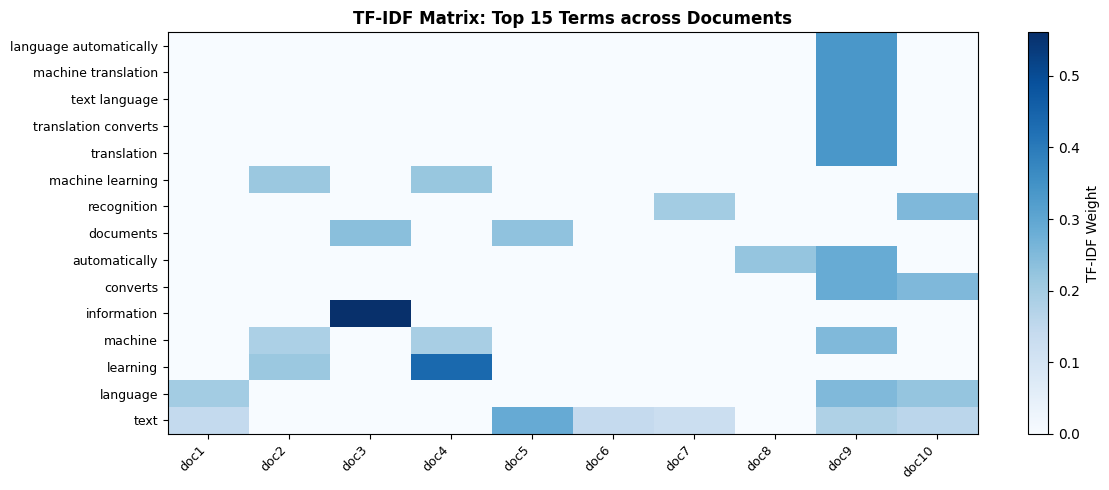

TF-IDF heatmap saved as 'tfidf_heatmap.png'


In [ ]:
# Run queries
queries = [
    "machine learning neural networks",
    "text mining opinion sentiment",
    "speech and language understanding",
]
for query in queries:
    print(f"\n  🔎 Query: \"{query}\"")
    results = retrieve(query, top_k=3)
    if results:
        for rank, (doc_id, score, text) in enumerate(results):
            print(f"    Rank {rank+1} [{doc_id}] score={score:.4f}: {text[:75]}...")
    else:
        print("    No relevant documents found.")

# Visualize TF-IDF matrix (heatmap of top terms)
terms = ir_vectorizer.get_feature_names_out()
tfidf_dense = tfidf_index.toarray()

# Pick top 15 terms by total TF-IDF weight
top_term_indices = np.argsort(tfidf_dense.sum(axis=0))[-15:]
top_terms = [terms[i] for i in top_term_indices]
top_tfidf = tfidf_dense[:, top_term_indices]

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(top_tfidf.T, aspect='auto', cmap='Blues')
ax.set_xticks(range(len(doc_ids)))
ax.set_xticklabels(doc_ids, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(top_terms)))
ax.set_yticklabels(top_terms, fontsize=9)
ax.set_title("TF-IDF Matrix: Top 15 Terms across Documents", fontweight='bold')
plt.colorbar(im, ax=ax, label='TF-IDF Weight')
plt.tight_layout()
plt.savefig("tfidf_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print("TF-IDF heatmap saved as 'tfidf_heatmap.png'")


### TOPIC 7: TEXT CATEGORIZATION

In [ ]:
# ================================================================
# TOPIC 7: TEXT CATEGORIZATION
# ================================================================
# 📜 HISTORICAL BACKGROUND
# • 1960s: Early automatic indexing used keyword frequencies (Luhn, 1958).
# • 1992: Joachims introduced SVMs for text categorization —
#   showed strong performance on Reuters corpus.
# • 1998: Reuters-21578 became the standard benchmark for text classification.
# • 2001: Yang & Pedersen — feature selection for text categorization.
# • 2012: Deep learning (CNNs for text) — Kim (2014) showed CNNs rival SVMs.
# • 2018+: BERT fine-tuning replaced hand-crafted features entirely.

In [ ]:
# ================================================================
print("\n" + "=" * 65)
print("📂 TOPIC 7: Text Categorization")
print("=" * 65)

# Dataset: News article headlines (multi-class: 4 categories)
headlines = [
    # Technology
    ("Google releases new AI model capable of complex reasoning tasks", "Technology"),
    ("Apple announces breakthrough in quantum computing chips", "Technology"),
    ("Scientists develop faster neural network for image recognition", "Technology"),
    ("New programming language promises 10x faster code execution", "Technology"),
    ("Researchers create AI that can write and debug code autonomously", "Technology"),
    ("Open source LLM beats GPT-4 on multiple benchmarks", "Technology"),

    # Sports
    ("India wins the cricket World Cup in a thrilling final", "Sports"),
    ("Federer announces surprise return to professional tennis", "Sports"),
    ("Premier League champions celebrate historic season with parade", "Sports"),
    ("Olympic sprinter breaks 100m world record by 0.02 seconds", "Sports"),
    ("Local football club advances to national championship semifinal", "Sports"),
    ("Basketball superstar signs record-breaking $300 million contract", "Sports"),

    # Politics
    ("Parliament passes landmark climate change legislation", "Politics"),
    ("Prime minister announces early elections amid economic crisis", "Politics"),
    ("United Nations debates ceasefire resolution for conflict region", "Politics"),
    ("Opposition party wins majority in surprise election upset", "Politics"),
    ("Government increases defence budget by 15 percent", "Politics"),
    ("New trade agreement signed between three major economies", "Politics"),

    # Health
    ("Scientists discover promising new treatment for Alzheimer's disease", "Health"),
    ("WHO reports decline in global malaria deaths for fifth consecutive year", "Health"),
    ("Study links processed food consumption to increased anxiety risk", "Health"),
    ("New vaccine shows 95 percent efficacy against drug-resistant tuberculosis", "Health"),
    ("Exercise found to reduce risk of dementia by 40 percent in new study", "Health"),
    ("Medical researchers achieve breakthrough in cancer immunotherapy", "Health"),
]

texts_cat  = [h[0] for h in headlines]
labels_cat = [h[1] for h in headlines]

# Preprocessing
processed_cat = [preprocess(t) for t in texts_cat]

# Train-test split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    processed_cat, labels_cat, test_size=0.25, random_state=42, stratify=labels_cat
)

# Feature extraction
vec_cat = TfidfVectorizer(ngram_range=(1,2), min_df=1)
X_train_cv = vec_cat.fit_transform(X_train_c)
X_test_cv  = vec_cat.transform(X_test_c)

print(f"\n  Training: {len(X_train_c)} | Test: {len(X_test_c)} examples")
print(f"  Categories: {sorted(set(labels_cat))}")
print(f"  Vocabulary: {len(vec_cat.vocabulary_)} terms")



📂 TOPIC 7: Text Categorization

  Training: 18 | Test: 6 examples
  Categories: ['Health', 'Politics', 'Sports', 'Technology']
  Vocabulary: 212 terms


In [ ]:

# Model: LinearSVC (strong for multi-class text classification)
svm_cat = LinearSVC(max_iter=1000)
svm_cat.fit(X_train_cv, y_train_c)
svm_preds_c = svm_cat.predict(X_test_cv)

nb_cat = MultinomialNB()
nb_cat.fit(X_train_cv, y_train_c)
nb_preds_c = nb_cat.predict(X_test_cv)

print(f"\n  LinearSVC Accuracy:   {accuracy_score(y_test_c, svm_preds_c):.2%}")
print(f"  Naive Bayes Accuracy: {accuracy_score(y_test_c, nb_preds_c):.2%}")
print("\n  LinearSVC Classification Report:")
print(classification_report(y_test_c, svm_preds_c, zero_division=0))

# Predict on new headlines
new_headlines = [
    "New AI chip outperforms NVIDIA GPU in benchmark tests",
    "National football team qualifies for world championship",
    "Health ministry launches vaccination drive for children",
    "President signs new immigration reform bill into law",
]
print("  Predicting categories for new headlines:")
new_processed = [preprocess(h) for h in new_headlines]
new_vec = vec_cat.transform(new_processed)
new_preds = svm_cat.predict(new_vec)
for headline, pred in zip(new_headlines, new_preds):
    print(f"    [{pred:12}] {headline}")



  LinearSVC Accuracy:   33.33%
  Naive Bayes Accuracy: 16.67%

  LinearSVC Classification Report:
              precision    recall  f1-score   support

      Health       0.50      0.50      0.50         2
    Politics       0.25      1.00      0.40         1
      Sports       0.00      0.00      0.00         2
  Technology       0.00      0.00      0.00         1

    accuracy                           0.33         6
   macro avg       0.19      0.38      0.23         6
weighted avg       0.21      0.33      0.23         6

  Predicting categories for new headlines:
    [Technology  ] New AI chip outperforms NVIDIA GPU in benchmark tests
    [Sports      ] National football team qualifies for world championship
    [Health      ] Health ministry launches vaccination drive for children
    [Politics    ] President signs new immigration reform bill into law


### TOPIC 8: TEXT SUMMARIZATION

In [ ]:
# ================================================================
# TOPIC 8: TEXT SUMMARIZATION
# ================================================================
# 📜 HISTORICAL BACKGROUND
# • 1958: Hans Peter Luhn (IBM) — first automatic summarization system.
#   Selected "significant" sentences based on word frequency clusters.
# • 1969: Edmundson extended Luhn with positional cues and title words.
# • 1990s: Extractive summarization became standard; TextRank (2004)
#   applied Google's PageRank idea to sentence graphs.
# • 2015: Rush et al. — first neural (LSTM) abstractive summarizer.
# • 2019: BART and T5 (Google) — pretrained transformer models that
#   generate fluent, abstractive summaries via sequence-to-sequence learning.


📝 TOPIC 8: Text Summarization (Extractive + Abstractive)

─── PART A: Extractive Summarization (TF-IDF Sentence Scoring) ───

  Original text: 9 sentences, 160 words

  EXTRACTIVE SUMMARY (top 3 sentences):
  These models, trained on vast amounts of text,
can generate human-like writing, answer complex questions, and perform a wide range
of language tasks. Natural language processing, once limited to simple keyword matching,
now powers sophisticated applications like chatbots, translation systems, and
content generators. The future promises even more capable systems that seamlessly bridge
the gap between human and machine communication, raising important ethical questions
about authenticity, privacy, and the role of AI in society.

  Compression ratio: 46.25%


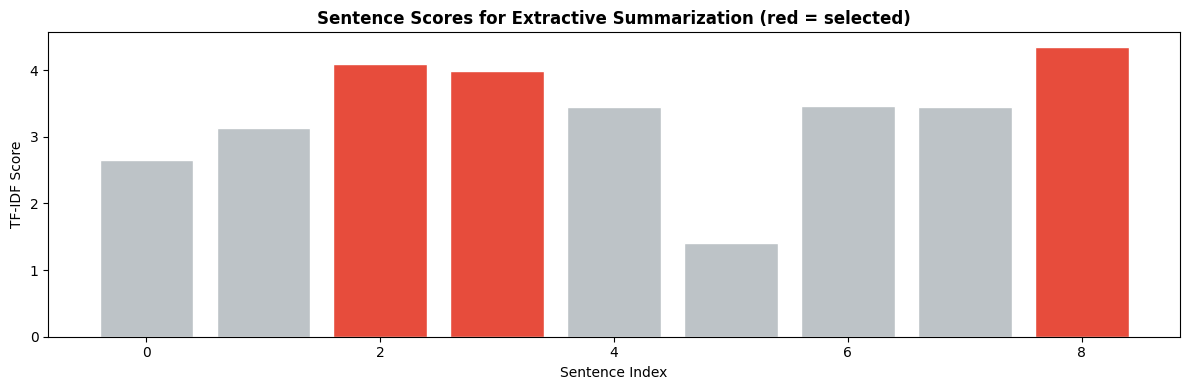

In [ ]:
# ================================================================
print("\n" + "=" * 65)
print("📝 TOPIC 8: Text Summarization (Extractive + Abstractive)")
print("=" * 65)

long_text = """
Artificial intelligence has undergone remarkable transformation over the past decade.
The development of large language models has fundamentally changed how we interact
with computers and process information. These models, trained on vast amounts of text,
can generate human-like writing, answer complex questions, and perform a wide range
of language tasks. Natural language processing, once limited to simple keyword matching,
now powers sophisticated applications like chatbots, translation systems, and
content generators. Researchers continue to push boundaries, developing models that
understand context, nuance, and even emotional tone in text. However, challenges remain.
Issues such as bias in training data, hallucinations, and the environmental cost of
training large models are active areas of research and debate. Despite these challenges,
AI-powered language tools have become integral to healthcare, education, business, and
creative industries. The future promises even more capable systems that seamlessly bridge
the gap between human and machine communication, raising important ethical questions
about authenticity, privacy, and the role of AI in society.
"""

# ── PART A: Extractive Summarization (Sentence Scoring) ──
print("\n─── PART A: Extractive Summarization (TF-IDF Sentence Scoring) ───")

def extractive_summarize(text, num_sentences=3):
    """
    Luhn/TextRank-inspired extractive summarization:
    1. Score each sentence by average TF-IDF of its words.
    2. Return top-N sentences in original order.
    """
    sentences = sent_tokenize(text.strip())
    if len(sentences) <= num_sentences:
        return text

    # Build TF-IDF on sentences
    tfidf = TfidfVectorizer(stop_words='english')
    tfidf_matrix = tfidf.fit_transform(sentences)

    # Score each sentence = mean TF-IDF of its words
    sentence_scores = np.array(tfidf_matrix.sum(axis=1)).flatten()

    # Pick top-N sentences, preserve original order
    top_indices = sorted(np.argsort(sentence_scores)[-num_sentences:])
    summary = ' '.join([sentences[i] for i in top_indices])
    return summary, sentence_scores, sentences

summary, scores, all_sents = extractive_summarize(long_text, num_sentences=3)
print(f"\n  Original text: {len(sent_tokenize(long_text))} sentences, {len(long_text.split())} words")
print(f"\n  EXTRACTIVE SUMMARY (top 3 sentences):")
print(f"  {summary}")
print(f"\n  Compression ratio: {len(summary.split()) / len(long_text.split()):.2%}")

# Visualize sentence scores
fig, ax = plt.subplots(figsize=(12, 4))
colors = ['#e74c3c' if s in sorted(scores)[-3:] else '#bdc3c7' for s in scores]
ax.bar(range(len(scores)), scores, color=colors, edgecolor='white')
ax.set_xlabel("Sentence Index")
ax.set_ylabel("TF-IDF Score")
ax.set_title("Sentence Scores for Extractive Summarization (red = selected)", fontweight='bold')
plt.tight_layout()
plt.savefig("summarization_scores.png", dpi=150, bbox_inches='tight')
plt.show()


In [ ]:

# ── PART B: Abstractive Summarization (HuggingFace BART/T5) ──
print("\n─── PART B: Abstractive Summarization (BART/T5 via HuggingFace) ───")
try:
    from transformers import pipeline
    summarizer = pipeline("summarization", model="sshleifer/distilbart-cnn-12-6")
    abstractive_summary = summarizer(
        long_text,
        max_length=80,
        min_length=30,
        do_sample=False
    )[0]['summary_text']
    print(f"\n  ABSTRACTIVE SUMMARY (DistilBART):")
    print(f"  {abstractive_summary}")
except Exception as e:
    print(f"  [Abstractive summarization requires transformers + torch. Error: {e}]")
    print("  → Install: !pip install transformers torch")
    print("  → Abstractive models (BART, T5) GENERATE new text, unlike extractive methods.")



─── PART B: Abstractive Summarization (BART/T5 via HuggingFace) ───


config.json: 0.00B [00:00, ?B/s]

  [Abstractive summarization requires transformers + torch. Error: "Unknown task summarization, available tasks are ['any-to-any', 'audio-classification', 'automatic-speech-recognition', 'depth-estimation', 'document-question-answering', 'feature-extraction', 'fill-mask', 'image-classification', 'image-feature-extraction', 'image-segmentation', 'image-text-to-text', 'image-to-image', 'keypoint-matching', 'mask-generation', 'ner', 'object-detection', 'question-answering', 'sentiment-analysis', 'table-question-answering', 'text-classification', 'text-generation', 'text-to-audio', 'text-to-speech', 'token-classification', 'video-classification', 'visual-question-answering', 'vqa', 'zero-shot-audio-classification', 'zero-shot-classification', 'zero-shot-image-classification', 'zero-shot-object-detection', 'translation_XX_to_YY']"]
  → Install: !pip install transformers torch
  → Abstractive models (BART, T5) GENERATE new text, unlike extractive methods.


### TOPIC 9: SENTIMENT ANALYSIS

In [ ]:
# ================================================================
# TOPIC 9: SENTIMENT ANALYSIS
# ================================================================
# 📜 HISTORICAL BACKGROUND
# • 1950s–70s: Lexical approaches — manually tagged positive/negative word lists.
#   Osgood's Semantic Differential (1957) — early framework for measuring sentiment.
# • 2002: Pang, Lee & Vaithyanathan — first ML-based sentiment analysis
#   using Naive Bayes and SVMs on movie reviews.
# • 2004: Hu & Liu — aspect-based sentiment analysis (ABSA) for product reviews.
# • 2011: VADER (Hutto & Gilbert) — rule-based lexicon optimized for social media text.
# • 2013: Socher et al.'s Recursive Neural Network with Stanford Sentiment Treebank (SST).
# • 2018+: BERT fine-tuning achieves state-of-the-art on all sentiment benchmarks.

In [ ]:
# ================================================================
print("\n" + "=" * 65)
print("😊 TOPIC 9: Sentiment Analysis")
print("=" * 65)

# ── PART A: Lexicon-Based Sentiment (VADER) ──
print("\n─── PART A: VADER (Rule-Based Lexicon, Best for Social Media) ───")

try:
    from nltk.sentiment.vader import SentimentIntensityAnalyzer
    nltk.download('vader_lexicon', quiet=True)
    sia = SentimentIntensityAnalyzer()

    vader_examples = [
        "This movie was absolutely fantastic! I loved every minute of it.",
        "The product broke after one day. Terrible quality. Total waste of money.",
        "It's okay. Not great, not terrible. Average experience.",
        "WORST customer service EVER!!! Never buying from here again!!!",
        "Surprisingly decent for the price. Wouldn't buy again but not bad.",
        "The NLP lecture was incredibly insightful and well-structured.",
        "I can't believe how bad this food is 😤 completely inedible.",
    ]

    print(f"\n  {'Text':55} {'neg':5} {'neu':5} {'pos':5} {'compound':8} Sentiment")
    print(f"  {'-'*90}")
    for text in vader_examples:
        scores = sia.polarity_scores(text)
        if scores['compound'] >= 0.05:   label = "😊 POSITIVE"
        elif scores['compound'] <= -0.05: label = "😞 NEGATIVE"
        else:                             label = "😐 NEUTRAL"
        print(f"  {text[:54]:55} {scores['neg']:.2f}  {scores['neu']:.2f}  {scores['pos']:.2f}  {scores['compound']:6.3f}  {label}")

except Exception as e:
    print(f"  [VADER error: {e}]")




😊 TOPIC 9: Sentiment Analysis

─── PART A: VADER (Rule-Based Lexicon, Best for Social Media) ───

  Text                                                    neg   neu   pos   compound Sentiment
  ------------------------------------------------------------------------------------------
  This movie was absolutely fantastic! I loved every min  0.00  0.49  0.51   0.854  😊 POSITIVE
  The product broke after one day. Terrible quality. Tot  0.49  0.51  0.00  -0.827  😞 NEGATIVE
  It's okay. Not great, not terrible. Average experience  0.44  0.41  0.15  -0.549  😞 NEGATIVE
  WORST customer service EVER!!! Never buying from here   0.43  0.57  0.00  -0.791  😞 NEGATIVE
  Surprisingly decent for the price. Wouldn't buy again   0.00  0.63  0.37   0.657  😊 POSITIVE
  The NLP lecture was incredibly insightful and well-str  0.00  1.00  0.00   0.000  😐 NEUTRAL
  I can't believe how bad this food is 😤 completely ined  0.00  0.74  0.26   0.431  😊 POSITIVE


In [ ]:

# ── PART B: ML-Based Sentiment (Naive Bayes, Logistic Regression) ──
print("\n─── PART B: ML-Based Sentiment (Train on Labeled Reviews) ───")

# Labeled reviews dataset
reviews = [
    ("Absolutely loved it! Great performance and fantastic design.", 1),
    ("Best product I've ever bought. Highly recommend to everyone.", 1),
    ("Works perfectly. Setup was easy and instructions were clear.", 1),
    ("Amazing quality. Exceeded all my expectations. Five stars!", 1),
    ("Wonderful experience. Customer support was also very helpful.", 1),
    ("Good value for money. Would purchase again without hesitation.", 1),
    ("Excellent build quality and fast delivery. Very satisfied.", 1),
    ("Terrible product. Stopped working after two days of use.", 0),
    ("Worst purchase ever. Completely useless. Total waste of money.", 0),
    ("Very disappointed. The quality is far below what was advertised.", 0),
    ("Broke immediately. Customer service was unhelpful and rude.", 0),
    ("Do not buy this. It's cheap rubbish that doesn't work.", 0),
    ("Horrible experience. Late delivery and damaged packaging.", 0),
    ("Awful product. Nothing like the description. Very misleading.", 0),
]

rev_texts  = [preprocess(r[0]) for r in reviews]
rev_labels = [r[1] for r in reviews]

X_tr, X_te, y_tr, y_te = train_test_split(rev_texts, rev_labels, test_size=0.25, random_state=42)
vec_sent = CountVectorizer(ngram_range=(1,2))
X_tr_v = vec_sent.fit_transform(X_tr)
X_te_v = vec_sent.transform(X_te)

nb_sent = MultinomialNB()
nb_sent.fit(X_tr_v, y_tr)
print(f"\n  Naive Bayes Sentiment Accuracy: {accuracy_score(y_te, nb_sent.predict(X_te_v)):.2%}")

lr_sent = LogisticRegression(max_iter=500)
lr_sent.fit(X_tr_v, y_tr)
print(f"  Logistic Regression Accuracy: {accuracy_score(y_te, lr_sent.predict(X_te_v)):.2%}")

# Test on new reviews
new_reviews = [
    "This is an outstanding product. Absolutely perfect.",
    "Completely broken on arrival. Never buying again.",
    "It's fine I guess. Nothing special about it.",
]
new_processed_r = [preprocess(r) for r in new_reviews]
new_r_vec = vec_sent.transform(new_processed_r)
new_preds_r = lr_sent.predict(new_r_vec)
print("\n  New Review Predictions (LR):")
for rev, pred in zip(new_reviews, new_preds_r):
    label = "😊 POSITIVE" if pred == 1 else "😞 NEGATIVE"
    print(f"    {label}: {rev}")



─── PART B: ML-Based Sentiment (Train on Labeled Reviews) ───

  Naive Bayes Sentiment Accuracy: 25.00%
  Logistic Regression Accuracy: 25.00%

  New Review Predictions (LR):
    😊 POSITIVE: This is an outstanding product. Absolutely perfect.
    😊 POSITIVE: Completely broken on arrival. Never buying again.
    😊 POSITIVE: It's fine I guess. Nothing special about it.


In [ ]:

# ── PART C: Neural Sentiment (HuggingFace) ──
print("\n─── PART C: Transformer-Based Sentiment (DistilBERT) ───")
try:
    from transformers import pipeline
    neural_sa = pipeline("sentiment-analysis")
    neural_inputs = [
        "This product completely transformed my workflow. Incredible!",
        "Garbage. Absolute garbage. Don't waste your money.",
        "It's an average product. Does the job but nothing impressive.",
    ]
    neural_results = neural_sa(neural_inputs)
    print()
    for text, result in zip(neural_inputs, neural_results):
        print(f"  Text: {text[:60]}...")
        print(f"  → {result['label']}  (confidence: {result['score']:.4f})\n")
except Exception as e:
    print(f"  [Requires transformers + torch. Error: {e}]")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.



─── PART C: Transformer-Based Sentiment (DistilBERT) ───


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]


  Text: This product completely transformed my workflow. Incredible!...
  → POSITIVE  (confidence: 0.9999)

  Text: Garbage. Absolute garbage. Don't waste your money....
  → NEGATIVE  (confidence: 0.9991)

  Text: It's an average product. Does the job but nothing impressive...
  → NEGATIVE  (confidence: 0.9929)



### TOPIC 10: NLP EVALUATION METRICS

In [ ]:
# ================================================================
# TOPIC 10: NLP EVALUATION METRICS
# ================================================================
# 📜 HISTORICAL BACKGROUND
# • Accuracy, Precision, Recall, F1:
#   Originated in Information Retrieval (van Rijsbergen, 1979).
#   Adopted universally in NLP classification tasks by 1990s.
# • BLEU (Bilingual Evaluation Understudy):
#   Papineni et al., ACL 2002. First automatic MT evaluation metric.
#   Measures n-gram overlap between hypothesis and reference translations.
# • ROUGE (Recall-Oriented Understudy for Gisting Evaluation):
#   Lin, 2004. Designed for summarization evaluation.
#   Measures recall of n-gram overlap with reference summary.
# • METEOR, TER, BERTScore (2019):
#   Newer metrics addressing BLEU's weaknesses; use semantic similarity.

In [ ]:
# ================================================================
print("\n" + "=" * 65)
print("📐 TOPIC 10: NLP Evaluation Metrics")
print("=" * 65)

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

# ── METRIC 1: Classification Metrics (F1, Precision, Recall) ──
print("\n─── METRIC 1: Classification Metrics ───")

# Example: binary classification predictions
y_true = [1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1]
y_pred = [1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1]

TP = sum(1 for t, p in zip(y_true, y_pred) if t == 1 and p == 1)
FP = sum(1 for t, p in zip(y_true, y_pred) if t == 0 and p == 1)
FN = sum(1 for t, p in zip(y_true, y_pred) if t == 1 and p == 0)
TN = sum(1 for t, p in zip(y_true, y_pred) if t == 0 and p == 0)

accuracy  = (TP + TN) / len(y_true)
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\n  Confusion Matrix: TP={TP}, FP={FP}, FN={FN}, TN={TN}")
print(f"\n  {'Metric':20} {'Formula':35} {'Value':8}")
print(f"  {'-'*65}")
print(f"  {'Accuracy':20} {'(TP+TN)/(TP+TN+FP+FN)':35} {accuracy:.4f}")
print(f"  {'Precision':20} {'TP/(TP+FP)':35} {precision:.4f}")
print(f"  {'Recall':20} {'TP/(TP+FN)':35} {recall:.4f}")
print(f"  {'F1 Score':20} {'2*P*R/(P+R)':35} {f1:.4f}")




📐 TOPIC 10: NLP Evaluation Metrics

─── METRIC 1: Classification Metrics ───

  Confusion Matrix: TP=9, FP=2, FN=2, TN=7

  Metric               Formula                             Value   
  -----------------------------------------------------------------
  Accuracy             (TP+TN)/(TP+TN+FP+FN)               0.8000
  Precision            TP/(TP+FP)                          0.8182
  Recall               TP/(TP+FN)                          0.8182
  F1 Score             2*P*R/(P+R)                         0.8182


In [ ]:
# ── METRIC 2: BLEU Score (for MT) ──
print("\n─── METRIC 2: BLEU Score (for Machine Translation) ───")
try:
    from nltk.translate.bleu_score import sentence_bleu, corpus_bleu, SmoothingFunction

    reference_translations = [
        [["the", "cat", "sat", "on", "the", "mat"]],
        [["the", "dog", "played", "in", "the", "garden"]],
    ]
    hypothesis_translations = [
        ["the", "cat", "sat", "on", "the", "mat"],          # perfect
        ["a", "dog", "was", "playing", "in", "garden"],      # imperfect
    ]

    smoother = SmoothingFunction()
    print(f"\n  {'Reference':40} {'Hypothesis':40} {'BLEU-1':7} {'BLEU-4':7}")
    print(f"  {'-'*100}")
    for ref, hyp in zip(reference_translations, hypothesis_translations):
        bleu1 = sentence_bleu(ref, hyp, weights=(1,0,0,0), smoothing_function=smoother.method1)
        bleu4 = sentence_bleu(ref, hyp, weights=(0.25,0.25,0.25,0.25), smoothing_function=smoother.method1)
        ref_str = ' '.join(ref[0])
        hyp_str = ' '.join(hyp)
        print(f"  {ref_str:40} {hyp_str:40} {bleu1:.4f}  {bleu4:.4f}")

    print("\n  📖 BLEU interpretation: 1.0 = perfect match | 0.0 = no n-gram overlap")
    print("  🔑 BLEU-4 (4-gram) is the standard for MT evaluation.")
    print("  ⚠️  Limitation: BLEU penalizes valid paraphrases. BERTScore uses semantics.")

except Exception as e:
    print(f"  [BLEU: {e}]")



─── METRIC 2: BLEU Score (for Machine Translation) ───

  Reference                                Hypothesis                               BLEU-1  BLEU-4 
  ----------------------------------------------------------------------------------------------------
  the cat sat on the mat                   the cat sat on the mat                   1.0000  1.0000
  the dog played in the garden             a dog was playing in garden              0.5000  0.0537

  📖 BLEU interpretation: 1.0 = perfect match | 0.0 = no n-gram overlap
  🔑 BLEU-4 (4-gram) is the standard for MT evaluation.
  ⚠️  Limitation: BLEU penalizes valid paraphrases. BERTScore uses semantics.


In [ ]:

# ── METRIC 3: ROUGE Score (for Summarization) ──
print("\n─── METRIC 3: ROUGE Score (for Summarization) ───")
try:
    from rouge_score import rouge_scorer

    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

    reference_summary = "Natural language processing enables computers to understand and generate human language."
    hypothesis_summaries = [
        "NLP allows machines to process and generate human language.",     # close
        "Computers can now understand text using artificial intelligence.", # partial
        "The weather is nice today.",                                       # irrelevant
    ]

    print(f"\n  Reference: \"{reference_summary}\"\n")
    print(f"  {'Hypothesis':65} {'R1-F1':7} {'R2-F1':7} {'RL-F1':7}")
    print(f"  {'-'*95}")
    for hyp in hypothesis_summaries:
        scores = scorer.score(reference_summary, hyp)
        r1 = scores['rouge1'].fmeasure
        r2 = scores['rouge2'].fmeasure
        rl = scores['rougeL'].fmeasure
        print(f"  {hyp[:64]:65} {r1:.4f}  {r2:.4f}  {rl:.4f}")

    print("\n  📖 ROUGE-1: Unigram overlap | ROUGE-2: Bigram overlap | ROUGE-L: Longest common subsequence")
    print("  🔑 Higher ROUGE = more overlap with reference summary.")

except Exception as e:
    print(f"  [ROUGE: install with !pip install rouge-score. Error: {e}]")



─── METRIC 3: ROUGE Score (for Summarization) ───
  [ROUGE: install with !pip install rouge-score. Error: No module named 'rouge_score']



─── METRIC 4: Confusion Matrix Visualization ───


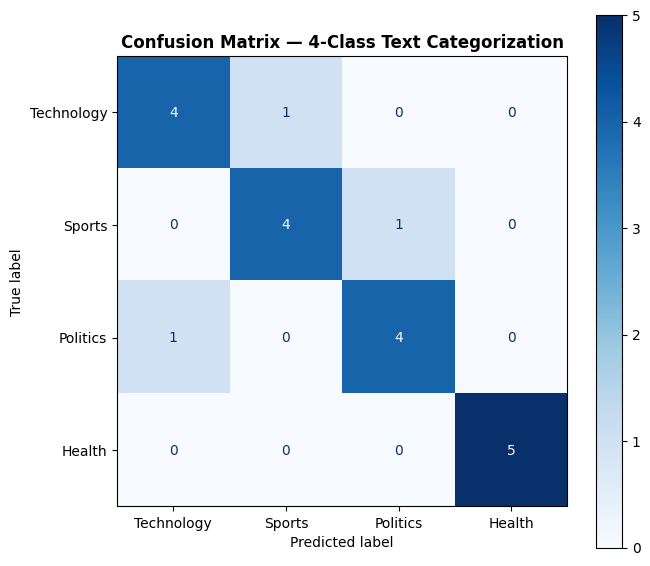

Confusion matrix saved as 'confusion_matrix.png'

📊 FINAL: NLP Evaluation Metrics — Summary Dashboard
   Metric             Task Range                      Notes
 Accuracy   Classification   0–1       Simple ratio correct
Precision   Classification   0–1      Avoid false positives
   Recall   Classification   0–1      Avoid false negatives
 F1 Score   Classification   0–1              Balance P & R
     BLEU               MT   0–1     N-gram precision, 2002
  ROUGE-1    Summarization   0–1        N-gram recall, 2004
BERTScore MT/Summarization   0–1 Semantic, BERT-based, 2019


In [ ]:

# ── METRIC 4: Confusion Matrix Visualization ──
print("\n─── METRIC 4: Confusion Matrix Visualization ───")
categories_labels = ['Technology', 'Sports', 'Politics', 'Health']
# Simulated predictions for a 4-class problem
y_true_cat = (['Technology']*5 + ['Sports']*5 + ['Politics']*5 + ['Health']*5)
y_pred_cat = (['Technology']*4 + ['Sports']*1 +   # 1 misclassified
               ['Sports']*4 + ['Politics']*1 +
               ['Politics']*4 + ['Technology']*1 +
               ['Health']*5)

cm = confusion_matrix(y_true_cat, y_pred_cat, labels=categories_labels)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=categories_labels)
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title("Confusion Matrix — 4-Class Text Categorization", fontweight='bold')
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved as 'confusion_matrix.png'")

# ── FINAL COMPARISON DASHBOARD ──
print("\n" + "=" * 65)
print("📊 FINAL: NLP Evaluation Metrics — Summary Dashboard")
print("=" * 65)

metrics_summary = pd.DataFrame({
    'Metric':    ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'BLEU',      'ROUGE-1',   'BERTScore'],
    'Task':      ['Classification', 'Classification', 'Classification', 'Classification',
                  'MT', 'Summarization', 'MT/Summarization'],
    'Range':     ['0–1', '0–1', '0–1', '0–1', '0–1', '0–1', '0–1'],
    'Notes':     ['Simple ratio correct', 'Avoid false positives',
                  'Avoid false negatives', 'Balance P & R',
                  'N-gram precision, 2002', 'N-gram recall, 2004',
                  'Semantic, BERT-based, 2019'],
})
print(metrics_summary.to_string(index=False))


In [ ]:
# ============================================================
# 📚 REFERENCES FOR FURTHER READING (Topics 4–10)
# ─────────────────────────────────────────────────
# Machine Translation:
#   • Brown et al. (1993) — IBM Model 1–5 — ACL Anthology
#   • Vaswani et al. (2017) — Attention Is All You Need
#     https://arxiv.org/abs/1706.03762
#   • HuggingFace MarianMT — https://huggingface.co/Helsinki-NLP
#
# Question Answering:
#   • Rajpurkar et al. (2016) — SQuAD: 100,000+ Questions for Machine Comprehension
#     https://arxiv.org/abs/1606.05250
#   • Katz (1997) — Annotating the World Wide Web using Natural Language
#
# Information Retrieval:
#   • Salton & McGill (1983) — Introduction to Modern Information Retrieval
#   • Manning, Raghavan & Schütze — Introduction to Information Retrieval (free online)
#     https://nlp.stanford.edu/IR-book/
#
# Text Categorization:
#   • Joachims (1998) — Text Categorization with Support Vector Machines
#   • Kim (2014) — Convolutional Neural Networks for Sentence Classification
#     https://arxiv.org/abs/1408.5882
#
# Summarization:
#   • Luhn (1958) — The Automatic Creation of Literature Abstracts
#   • Mihalcea & Tarau (2004) — TextRank: Bringing Order into Text
#   • BART: https://arxiv.org/abs/1910.13461
#
# Sentiment Analysis:
#   • Pang, Lee & Vaithyanathan (2002) — Thumbs Up? ACL
#   • VADER: Hutto & Gilbert (2014) — https://ojs.aaai.org/index.php/ICWSM
#   • SentimentIntensityAnalyzer docs — https://www.nltk.org/
#
# Evaluation Metrics:
#   • Papineni et al. (2002) — BLEU: https://aclanthology.org/P02-1040.pdf
#   • Lin (2004) — ROUGE: https://aclanthology.org/W04-1013.pdf
#   • Zhang et al. (2019) — BERTScore: https://arxiv.org/abs/1904.09675
#
# 🚀 SCOPE FOR ENHANCEMENT
# ──────────────────────────
# Topic 4 (MT): Train a seq2seq model from scratch using PyTorch on a bilingual corpus
# Topic 5 (QA): Fine-tune BERT on custom SQuAD-format data for domain-specific QA
# Topic 6 (IR): Replace TF-IDF with DPR (Dense Passage Retrieval) using FAISS index
# Topic 7 (TC): Fine-tune DistilBERT on AG News (4-class) for state-of-the-art accuracy
# Topic 8 (Summ): Compare extractive (TextRank) vs. abstractive (T5) on CNN/DailyMail
# Topic 9 (SA): Implement Aspect-Based Sentiment Analysis (ABSA) using spaCy + rules
# Topic 10 (Eval): Add BERTScore evaluation; implement per-class weighted F1 analysis
# General: Build a unified Flask/Streamlit web app that demos all 6 NLP applications

In [ ]:
# ============================================================

print("\n✅ All 10 NLP Module 1 Coding Topics Complete!")
print("\n📁 Output files generated:")
print("   • nlp_pipeline.png       — NLP Pipeline diagram")
print("   • ml_vs_rules.png        — ML vs Rule-Based comparison")
print("   • tfidf_heatmap.png      — TF-IDF document-term matrix")
print("   • summarization_scores.png — Sentence scoring visualization")
print("   • confusion_matrix.png   — Multi-class confusion matrix")
